<a href="https://colab.research.google.com/github/kseniaproshina2200-del/lab1-data-quality/blob/main/notebooks/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("✅ Библиотеки загружены.")

✅ Библиотеки загружены.


In [7]:
np.random.seed(42)
n = 1200

order_ids = list(range(1000, 1000 + n))
customer_ids = np.random.randint(1, 400, n)
order_dates = [datetime(2023, 1, 1) + timedelta(days=int(np.random.randint(0, 365))) for _ in range(n)]
categories = np.random.choice(['Electronics', 'Clothing', 'Books', 'Home', 'Sports'], n)
quantities = np.random.randint(1, 10, n)
unit_prices = np.round(np.random.uniform(5, 500, n), 2)
discounts = np.random.choice([0, 5, 10, 15, 20, 25], n)
ages = np.random.randint(18, 75, n)
cities = np.random.choice(['Moscow', 'SPb', 'Novosibirsk', 'Ekaterinburg', 'Kazan',
                           'Moscow ', 'spb', 'MOSCOW'], n)
delivery_days = np.random.randint(1, 15, n)
ratings = np.random.choice([1, 2, 3, 4, 5], n)
returned = np.random.choice(['Yes', 'No'], n, p=[0.1, 0.9])

df = pd.DataFrame({
    'order_id': order_ids,
    'customer_id': customer_ids,
    'order_date': order_dates,
    'product_category': categories,
    'quantity': quantities,
    'unit_price': unit_prices,
    'discount_percent': discounts,
    'customer_age': ages,
    'customer_city': cities,
    'delivery_days': delivery_days,
    'rating': ratings,
    'is_returned': returned
})

# --- Искусственные дефекты качества ---

# 1. Пропуски
for col in ['customer_age', 'rating', 'customer_city', 'delivery_days']:
    mask = np.random.random(n) < 0.08
    df.loc[mask, col] = np.nan

# 2. Дубликаты
dup_rows = df.sample(15, random_state=1)
df = pd.concat([df, dup_rows], ignore_index=True)

# 3. Невозможные значения
df.loc[df.sample(5, random_state=2).index, 'customer_age'] = -5

# 4. Выбросы
df.loc[df.sample(3, random_state=3).index, 'unit_price'] = 9999.99
df.loc[df.sample(2, random_state=4).index, 'delivery_days'] = 999

# 5. Пропуски в дате
df.loc[df.sample(3, random_state=5).index, 'order_date'] = pd.NaT

print(f"✅ Датасет создан. Размер: {df.shape}")
df.head()

✅ Датасет создан. Размер: (1215, 12)


,order_id,customer_id,order_date,product_category,quantity,unit_price,discount_percent,customer_age,customer_city,delivery_days,rating,is_returned
0,1000,103,2023-04-28,Clothing,6,467.91,25,60.0,Kazan,5.0,1.0,No
1,1001,349,2023-10-21,Home,7,191.02,25,45.0,Moscow,14.0,3.0,No
2,1002,271,2023-06-08,Clothing,5,355.52,20,45.0,Moscow,11.0,5.0,No
3,1003,107,2023-10-30,Electronics,7,240.47,5,25.0,Ekaterinburg,4.0,1.0,No
4,1004,72,2023-08-16,Books,1,338.83,10,40.0,Moscow,8.0,3.0,No


1. Постановка задачи (Business Understanding)

### 1.1. Что это за данные
Датасет — выгрузка заказов интернет-магазина за 2023 год. Каждая строка = один заказ:
ID заказа и клиента, дата оформления, категория товара, количество, цена, скидка,
возраст и город клиента, срок доставки, оценка и признак возврата.
Присутствуют числовые, категориальные и временные признаки, а также дефекты качества.

### 1.2. Условный «заказчик»
Отдел маркетинга и аналитики интернет-магазина. Цель — повысить продажи,
удержание клиентов и качество логистики.

### 1.3. Возможные задачи ИАД
1. **Сегментация клиентов** — по возрасту, городу, категориям покупок.
2. **Поиск аномалий** — подозрительные цены, скидки, возвраты.
3. **Описательная аналитика** — связь оценки клиента со сроком доставки.
4. **Поиск ассоциативных правил** — какие категории покупают вместе.

In [9]:

print("=" * 60)
print(f"Количество строк:    {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print("=" * 60)

info = pd.DataFrame({
    'Тип (pandas)': df.dtypes.astype(str),
    'Уникальных':   df.nunique(),
    'Пропусков':    df.isna().sum(),
})
info['Смысл (гипотеза)'] = [
    'Уникальный номер заказа',
    'ID клиента',
    'Дата оформления заказа',
    'Категория товара',
    'Количество единиц в заказе',
    'Цена за единицу (руб.)',
    'Скидка в %',
    'Возраст клиента',
    'Город клиента',
    'Срок доставки (дней)',
    'Оценка клиента (1–5)',
    'Признак возврата'
]
info

Количество строк:    1215
Количество столбцов: 12


,Тип (pandas),Уникальных,Пропусков,Смысл (гипотеза)
order_id,int64,1200,0,Уникальный номер заказа
customer_id,int64,371,0,ID клиента
order_date,datetime64[ns],351,3,Дата оформления заказа
product_category,object,5,0,Категория товара
quantity,int64,9,0,Количество единиц в заказе
unit_price,float64,1188,0,Цена за единицу (руб.)
discount_percent,int64,6,0,Скидка в %
customer_age,float64,58,91,Возраст клиента
customer_city,object,8,100,Город клиента
delivery_days,float64,15,102,Срок доставки (дней)


In [10]:
df['order_date']       = pd.to_datetime(df['order_date'], errors='coerce')
df['product_category'] = df['product_category'].astype('category')
df['is_returned']      = df['is_returned'].astype('category')
df['rating']           = df['rating'].astype('Int64')

print("✅ Типы после приведения:")
print(df.dtypes)

✅ Типы после приведения:
order_id                     int64
customer_id                  int64
order_date          datetime64[ns]
product_category          category
quantity                     int64
unit_price                 float64
discount_percent             int64
customer_age               float64
customer_city               object
delivery_days              float64
rating                       Int64
is_returned               category
dtype: object


,Пропусков,"Доля, %"
delivery_days,102,8.40
customer_city,100,8.23
rating,97,7.98
customer_age,91,7.49
order_date,3,0.25
product_category,0,0.00
order_id,0,0.00
customer_id,0,0.00
discount_percent,0,0.00
unit_price,0,0.00


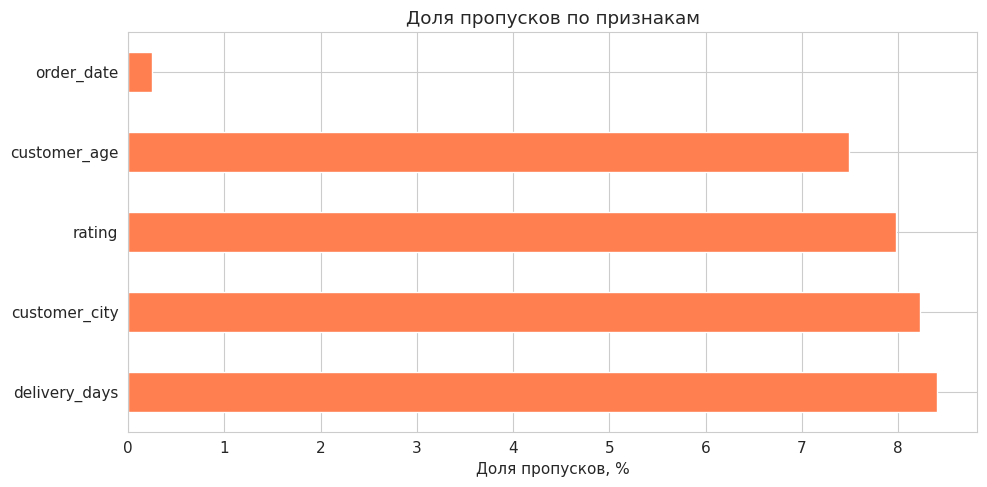

In [11]:
missing = pd.DataFrame({
    'Пропусков': df.isna().sum(),
    'Доля, %':  (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('Пропусков', ascending=False)

display(missing)

fig, ax = plt.subplots(figsize=(10, 5))
missing[missing['Пропусков'] > 0]['Доля, %'].plot(kind='barh', color='coral', ax=ax)
ax.set_xlabel('Доля пропусков, %')
ax.set_title('Доля пропусков по признакам')
plt.tight_layout()
plt.show()

In [12]:
full_dups = df.duplicated().sum()
print(f"Полных дубликатов: {full_dups}")

id_dups = df.duplicated(subset=['order_id']).sum()
print(f"Дубликатов по order_id: {id_dups}")

if full_dups > 0:
    display(df[df.duplicated(keep=False)].sort_values('order_id').head(10))

Полных дубликатов: 14
Дубликатов по order_id: 15


,order_id,customer_id,order_date,product_category,quantity,unit_price,discount_percent,customer_age,customer_city,delivery_days,rating,is_returned
135,1135,227,2023-06-24,Home,5,391.09,5,22.0,Ekaterinburg,6.0,3,No
1211,1135,227,2023-06-24,Home,5,391.09,5,22.0,Ekaterinburg,6.0,3,No
1213,1189,225,2023-04-22,Clothing,3,42.90,20,58.0,Kazan,8.0,5,No
189,1189,225,2023-04-22,Clothing,3,42.90,20,58.0,Kazan,8.0,5,No
190,1190,385,2023-02-05,Books,9,213.28,15,36.0,Kazan,7.0,<NA>,No
1203,1190,385,2023-02-05,Books,9,213.28,15,36.0,Kazan,7.0,<NA>,No
1210,1239,160,2023-10-20,Home,2,146.42,20,28.0,Ekaterinburg,3.0,1,No
239,1239,160,2023-10-20,Home,2,146.42,20,28.0,Ekaterinburg,3.0,1,No
283,1283,346,2023-10-23,Home,4,444.12,20,47.0,spb,7.0,4,No
1205,1283,346,2023-10-23,Home,4,444.12,20,47.0,spb,7.0,4,No


In [13]:
num_cols = ['quantity', 'unit_price', 'discount_percent',
            'customer_age', 'delivery_days', 'rating']
print("Числовая статистика:")
display(df[num_cols].describe().T.round(2))

print("\n--- Подозрительные значения ---")
print(f"Возраст < 0:          {(df['customer_age'] < 0).sum()}")
print(f"Возраст > 100:        {(df['customer_age'] > 100).sum()}")
print(f"Цена <= 0:            {(df['unit_price'] <= 0).sum()}")
print(f"Скидка вне [0, 100]:  {((df['discount_percent'] < 0) | (df['discount_percent'] > 100)).sum()}")
print(f"Срок доставки > 60:   {(df['delivery_days'] > 60).sum()}")

print("\n--- Категориальные признаки ---")
for col in ['product_category', 'customer_city', 'is_returned']:
    print(f"\n{col}: {df[col].nunique()} уникальных")
    print(df[col].value_counts(dropna=False).head(10))

Числовая статистика:


,count,mean,std,min,25%,50%,75%,max
quantity,1215.0,5.024691,2.594707,1.0,3.0,5.0,7.0,9.0
unit_price,1215.0,270.401185,505.376187,5.09,120.265,240.85,376.32,9999.99
discount_percent,1215.0,12.534979,8.50149,0.0,5.0,15.0,20.0,25.0
customer_age,1124.0,45.430605,16.576426,-5.0,32.0,45.0,59.0,74.0
delivery_days,1113.0,9.267745,42.214639,1.0,4.0,8.0,11.0,999.0
rating,1118.0,3.079606,1.438041,1.0,2.0,3.0,4.0,5.0



--- Подозрительные значения ---
Возраст < 0:          5
Возраст > 100:        0
Цена <= 0:            0
Скидка вне [0, 100]:  0
Срок доставки > 60:   2

--- Категориальные признаки ---

product_category: 5 уникальных
product_category
Home           267
Sports         249
Books          243
Electronics    236
Clothing       220
Name: count, dtype: int64

customer_city: 8 уникальных
customer_city
Moscow          151
SPb             151
Kazan           144
spb             137
Ekaterinburg    136
MOSCOW          136
Moscow          134
Novosibirsk     126
NaN             100
Name: count, dtype: int64

is_returned: 2 уникальных
is_returned
No     1102
Yes     113
Name: count, dtype: int64


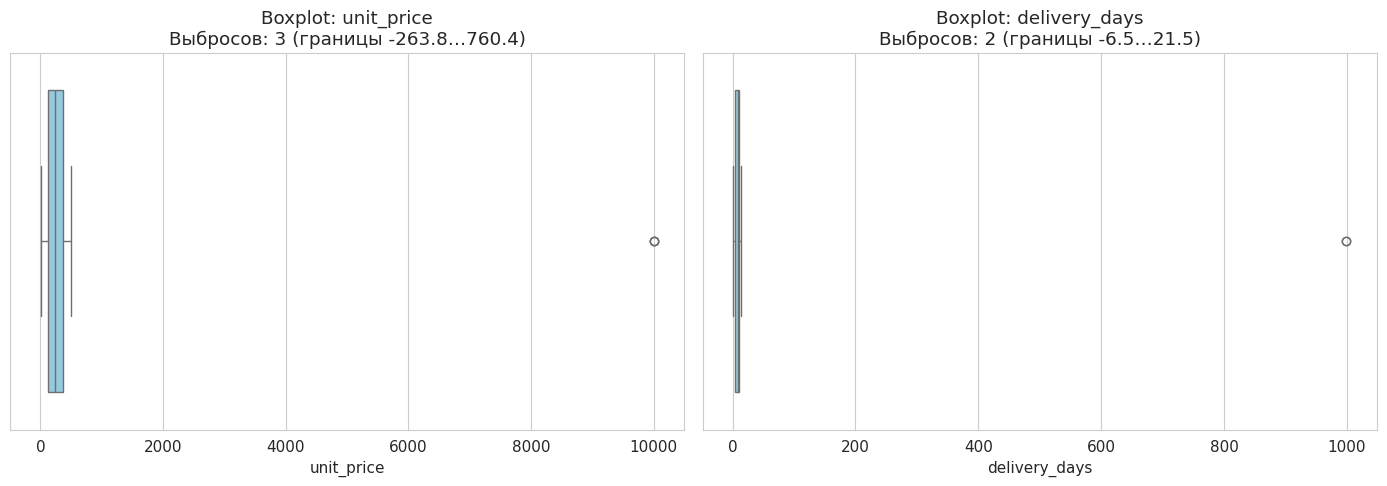

In [14]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    return mask, low, high

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['unit_price', 'delivery_days']):
    mask, low, high = iqr_outliers(df[col].dropna())
    sns.boxplot(x=df[col], ax=ax, color='skyblue')
    ax.set_title(f'Boxplot: {col}\nВыбросов: {mask.sum()} (границы {low:.1f}…{high:.1f})')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

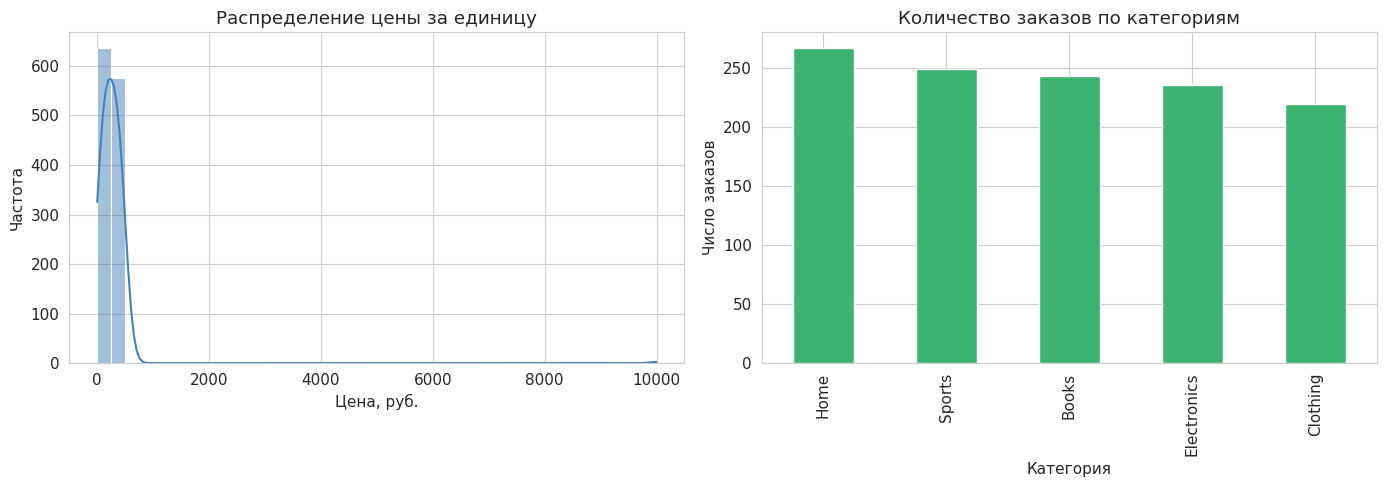

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['unit_price'].dropna(), bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение цены за единицу')
axes[0].set_xlabel('Цена, руб.')
axes[0].set_ylabel('Частота')

df['product_category'].value_counts().plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Количество заказов по категориям')
axes[1].set_xlabel('Категория')
axes[1].set_ylabel('Число заказов')

plt.tight_layout()
plt.show()

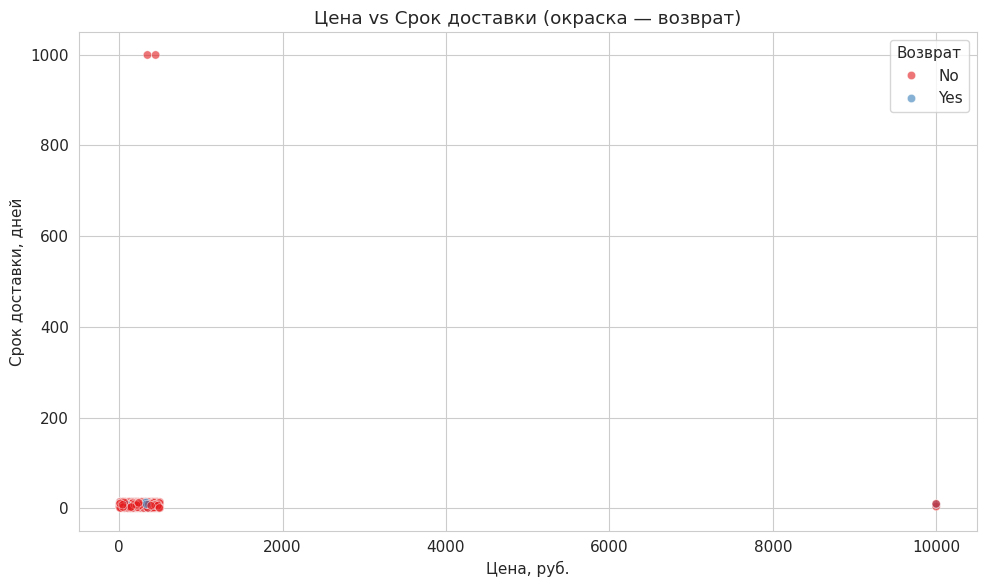

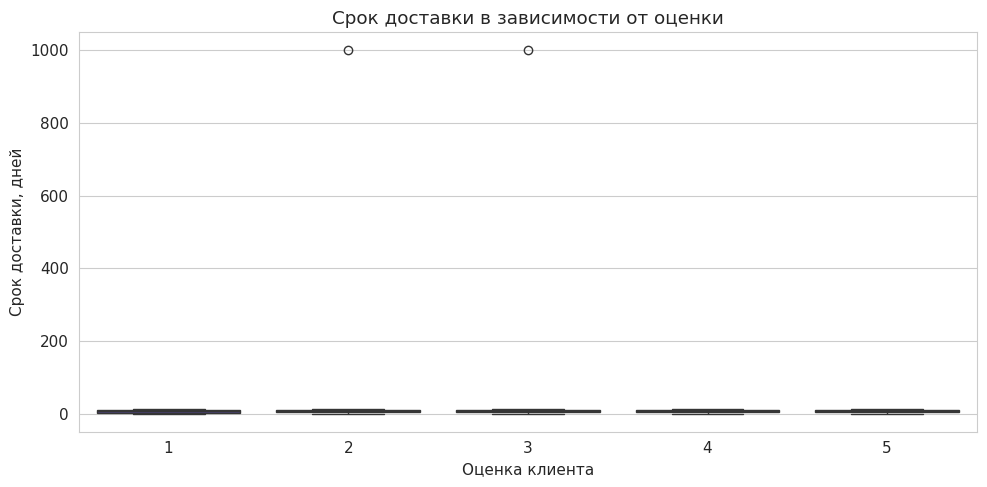

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='unit_price', y='delivery_days',
                hue='is_returned', alpha=0.6, palette='Set1')
plt.title('Цена vs Срок доставки (окраска — возврат)')
plt.xlabel('Цена, руб.')
plt.ylabel('Срок доставки, дней')
plt.legend(title='Возврат')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='rating', y='delivery_days', palette='viridis')
plt.title('Срок доставки в зависимости от оценки')
plt.xlabel('Оценка клиента')
plt.ylabel('Срок доставки, дней')
plt.tight_layout()
plt.show()

In [17]:
df.to_csv('orders_raw.csv', index=False)

df_clean = df.drop_duplicates().copy()
df_clean = df_clean[df_clean['customer_age'].between(0, 100) | df_clean['customer_age'].isna()]
df_clean = df_clean[df_clean['unit_price'] < 5000]
df_clean = df_clean[df_clean['delivery_days'] <= 60]
df_clean.to_csv('orders_clean.csv', index=False)

print(f"Сырой: {df.shape}")
print(f"Очищенный: {df_clean.shape}")

Сырой: (1215, 12)
Очищенный: (1090, 12)


In [18]:
from google.colab import files
files.download('orders_raw.csv')
files.download('orders_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>